In [ ]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
from torchvision import datasets, transforms
%matplotlib inline

In [ ]:
dataset =  MNIST(root='data',download=True, transform=ToTensor())

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.42MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


In [ ]:
val_size = 10000
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])
len(train_ds), len(val_ds)

(50000, 10000)

In [ ]:
batch_size = 128

In [ ]:
train_loader = DataLoader(dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size*2, num_workers=2, pin_memory=True)

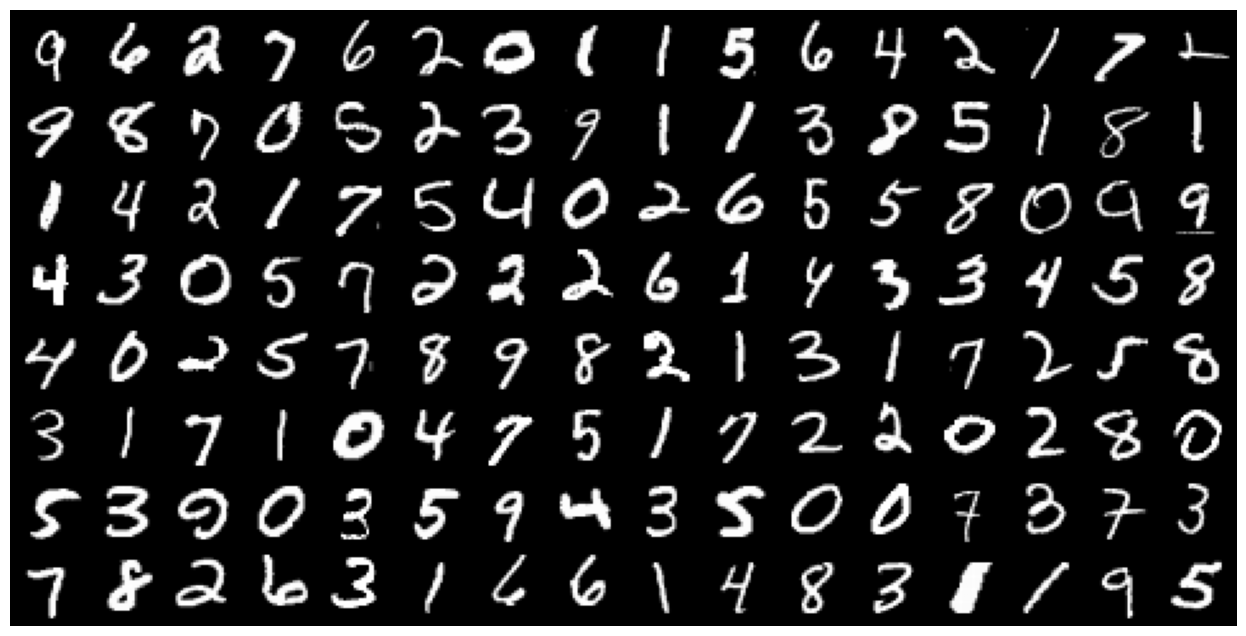

In [ ]:
for images, _ in train_loader:
    grid = make_grid(images, nrow=16)

    plt.figure(figsize=(16, 8))
    plt.axis('off')
    plt.imshow(grid.permute(1, 2, 0).cpu(), cmap='gray')
    break


In [ ]:
def accuracy(outputs, labels):
  _, preds = torch.max(outputs, dim=1)
  return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [ ]:
class MnistModel(nn.Module):
  '''Feedforward neural network with 1 hidden layer'''
  def __init__(self, in_size, hidden_size, out_size):
      super().__init__()
      # hiddden layer
      self.linear1 = nn.Linear(in_size, hidden_size)
      # output layer
      self.linear2 = nn.Linear(hidden_size, out_size)

  def forward(self, xb):
    # Flatten image tensors
    xb = xb.view(xb.size(0), -1)
    # Get intermediate output using hidden layer
    out = self.linear1(xb)
    # Apply activation function
    out = F.relu(out)
    # Get predictions using output layer
    out = self.linear2(out)
    return out

  def training_step(self, batch):
    images, labels = batch
    out = self(images)                      # Generate predictions
    loss = F.cross_entropy(out, labels)     # Calculate loss
    return loss

  def validation_step(self, batch):
    images, labels = batch
    out = self(images)                        # Generate predictions
    loss = F.cross_entropy(out, labels)       # Calculate loss
    acc = accuracy(out, labels)               # Calculate accuracy
    return {'val_loss': loss.detach(), 'val_acc': acc}

  def validation_epoch_end(self, outputs):
    batch_losses = [x['val_loss'] for x in outputs]
    epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
    batch_accs = [x['val_acc'] for x in outputs]
    epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
    return {'val_loss': epoch_loss.item(), 'val_acc':epoch_acc.item()}

  def epoch_end(self, epoch, results):
      print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, results['val_loss'], results['val_acc']))

In [ ]:
input_size = 784
hidden_size = 32
num_classes = 10

In [ ]:
model = MnistModel(input_size, hidden_size = 32, out_size = num_classes)

In [ ]:
model

MnistModel(
  (linear1): Linear(in_features=784, out_features=32, bias=True)
  (linear2): Linear(in_features=32, out_features=10, bias=True)
)

In [ ]:
for t in model.parameters():
  print(t.shape)

torch.Size([32, 784])
torch.Size([32])
torch.Size([10, 32])
torch.Size([10])


In [ ]:
for images, labels in train_loader:
  outputs = model(images)
  loss = F.cross_entropy(outputs, labels)
  print('loss:', loss.item())
  break

print('outputs.shape:', outputs.shape)
print('Sample outputs :\n', outputs[:2].data)

loss: 2.326586961746216
outputs.shape: torch.Size([128, 10])
Sample outputs :
 tensor([[-0.0274, -0.0347,  0.0303,  0.2093,  0.1909, -0.0899,  0.1777, -0.1070,
         -0.2069, -0.0361],
        [ 0.0315, -0.0150, -0.0596,  0.1689,  0.2478, -0.0945,  0.1619, -0.2301,
         -0.1322,  0.0010]])


In [ ]:
torch.cuda.is_available()

True

In [ ]:
def get_default_device():
  ''' Pick GPU if available, else CPU '''
  if torch.cuda.is_available():
    return torch.device('cuda')
  else:
    return torch.device('CPU')


In [ ]:
device =  get_default_device()
device

device(type='cuda')

In [ ]:
def to_device(data, device):
  ''' Move tensor(s) to chosen device'''
  if isinstance(data, (list,tuple)):
    return [to_device(x, device) for x in data]
  return data.to(device, non_blocking=True)

In [ ]:
for images, labels in train_loader:
  print(images.shape)
  images = to_device(images, device)
  print(images.device)
  break

torch.Size([128, 1, 28, 28])
cuda:0


In [ ]:
class DeviceDataLoader():
  ''' Wrap a data loader to move data to a device'''
  def __init__(self, dl, device):
    self.dl = dl
    self.device = device

  def __iter__(self):
    '''Yield a batch of data after moving it to device'''
    for b in self.dl:
      yield to_device(b, self.device)

  def __len__(self):
    ''' Number of batches'''
    return len(self.dl)

In [ ]:
train_loader = DeviceDataLoader(train_loader, device)
val_loader = DeviceDataLoader(val_loader, device)

In [ ]:
for xb, yb in val_loader:
  print('xb.device:', xb.device)
  print('yb:', yb)
  break

xb.device: cuda:0
yb: tensor([7, 8, 6, 3, 7, 5, 4, 6, 4, 9, 1, 1, 5, 9, 6, 6, 1, 6, 3, 4, 6, 8, 2, 2,
        0, 1, 7, 0, 3, 8, 7, 0, 4, 0, 6, 8, 7, 0, 1, 5, 2, 4, 4, 5, 7, 2, 8, 3,
        7, 7, 6, 2, 0, 1, 4, 9, 2, 1, 0, 9, 7, 6, 0, 9, 4, 1, 8, 4, 8, 6, 9, 0,
        3, 1, 7, 1, 9, 3, 8, 6, 9, 8, 6, 1, 3, 0, 1, 5, 7, 4, 1, 6, 7, 8, 6, 4,
        1, 0, 5, 3, 3, 8, 7, 7, 7, 4, 1, 0, 8, 5, 2, 2, 5, 6, 6, 4, 5, 1, 8, 9,
        1, 5, 3, 0, 8, 6, 9, 3, 9, 8, 2, 0, 9, 8, 4, 9, 2, 4, 3, 9, 2, 6, 1, 4,
        3, 6, 6, 9, 0, 9, 5, 3, 9, 0, 9, 2, 3, 0, 6, 9, 6, 9, 6, 3, 1, 5, 7, 2,
        2, 0, 5, 8, 0, 1, 5, 6, 3, 7, 8, 9, 2, 1, 4, 9, 0, 2, 0, 6, 0, 0, 6, 6,
        7, 2, 2, 9, 9, 8, 3, 5, 7, 3, 5, 2, 9, 1, 8, 8, 6, 7, 0, 7, 1, 5, 6, 2,
        6, 5, 5, 7, 6, 4, 5, 7, 0, 4, 5, 0, 3, 6, 1, 3, 3, 8, 7, 1, 5, 3, 8, 9,
        4, 0, 6, 4, 2, 5, 0, 1, 7, 8, 5, 9, 0, 4, 3, 4], device='cuda:0')


In [ ]:
def evaluate(model, val_loader):
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.Adam):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training phase
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # Validation phase
        result = evaluate (model, val_loader)
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [ ]:
# Model on GPU
model = MnistModel(in_size=input_size,hidden_size=hidden_size, out_size=num_classes)
to_device(model, device)

MnistModel(
  (linear1): Linear(in_features=784, out_features=32, bias=True)
  (linear2): Linear(in_features=32, out_features=10, bias=True)
)

In [ ]:
history = [evaluate(model, val_loader)]
history

[{'val_loss': 2.307720899581909, 'val_acc': 0.10361327975988388}]

In [ ]:
history1 = fit(5, 0.005,model,train_loader, val_loader)

Epoch [0], val_loss: 0.1904, val_acc: 0.9449
Epoch [1], val_loss: 0.1515, val_acc: 0.9555
Epoch [2], val_loss: 0.1071, val_acc: 0.9680
Epoch [3], val_loss: 0.1005, val_acc: 0.9682
Epoch [4], val_loss: 0.0928, val_acc: 0.9723


In [ ]:
history2 = fit(5, 0.005,model,train_loader, val_loader)

Epoch [0], val_loss: 0.0769, val_acc: 0.9755
Epoch [1], val_loss: 0.0740, val_acc: 0.9769
Epoch [2], val_loss: 0.0632, val_acc: 0.9801
Epoch [3], val_loss: 0.0658, val_acc: 0.9779
Epoch [4], val_loss: 0.0626, val_acc: 0.9807


In [ ]:
history3 = fit(5, 0.005,model,train_loader, val_loader)

Epoch [0], val_loss: 0.0525, val_acc: 0.9818
Epoch [1], val_loss: 0.0501, val_acc: 0.9843
Epoch [2], val_loss: 0.0496, val_acc: 0.9845
Epoch [3], val_loss: 0.0476, val_acc: 0.9836
Epoch [4], val_loss: 0.0417, val_acc: 0.9855


In [ ]:
history4 = fit(5, 0.0005,model,train_loader, val_loader)

Epoch [0], val_loss: 0.0104, val_acc: 0.9979
Epoch [1], val_loss: 0.0085, val_acc: 0.9982
Epoch [2], val_loss: 0.0079, val_acc: 0.9985
Epoch [3], val_loss: 0.0069, val_acc: 0.9989
Epoch [4], val_loss: 0.0067, val_acc: 0.9989


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Accuracy vs No. of epochs')

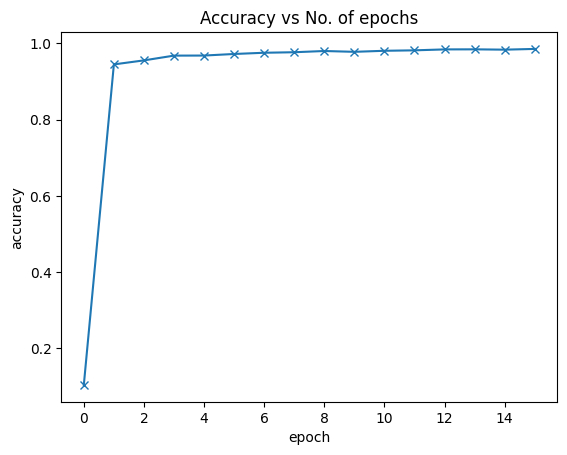

In [ ]:
history = history + history1 + history2 + history3 #+ history4
accuracies = [x['val_acc'] for x in history]
plt.plot(accuracies, '-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy vs No. of epochs')

Text(0.5, 1.0, 'Loss vs No. of epochs')

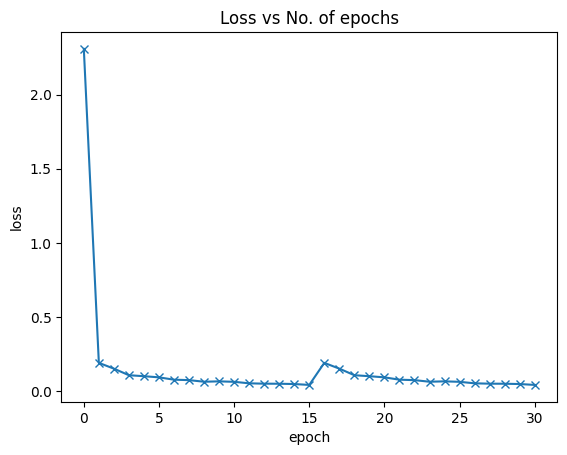

In [ ]:
history = history + history1 + history2 + history3 #+ history4
losses = [x['val_loss'] for x in history]
plt.plot(losses, '-x')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss vs No. of epochs')

In [ ]:
test_dataset = MNIST(
    root='data',
    train=False,
    transform=transforms.ToTensor()
)

Shape: torch.Size([1, 28, 28])
Label 7


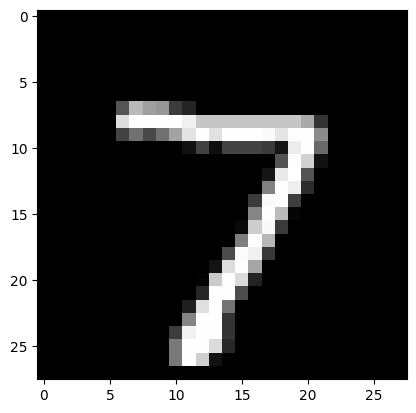

In [ ]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap='gray')
print('Shape:', img.shape)
print('Label', label)

In [ ]:
img.unsqueeze(0).shape

torch.Size([1, 1, 28, 28])

In [ ]:
def predict_image(img, model):
    device = next(model.parameters()).device   # get model device

    img = img.unsqueeze(0).to(device)           # add batch dim + move to GPU

    model.eval()
    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, dim=1)

    return preds.item()

Label: 7 , Predicted: 7


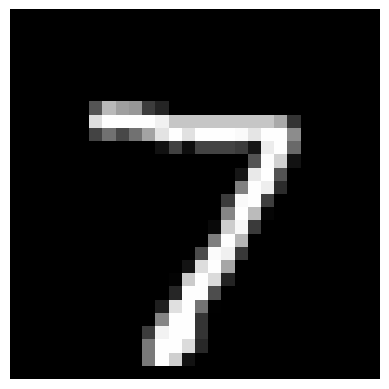

In [ ]:
img, label = test_dataset[0]

plt.imshow(img[0], cmap='gray')
plt.axis('off')

print('Label:', label, ', Predicted:', predict_image(img, model))
